In [3]:
import pandas as pd

cols = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
df = pd.read_csv("4) house Prediction Data Set.csv", sep=r'\s+', header=None, names=cols)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
model = scaler.fit_transform(df)

C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

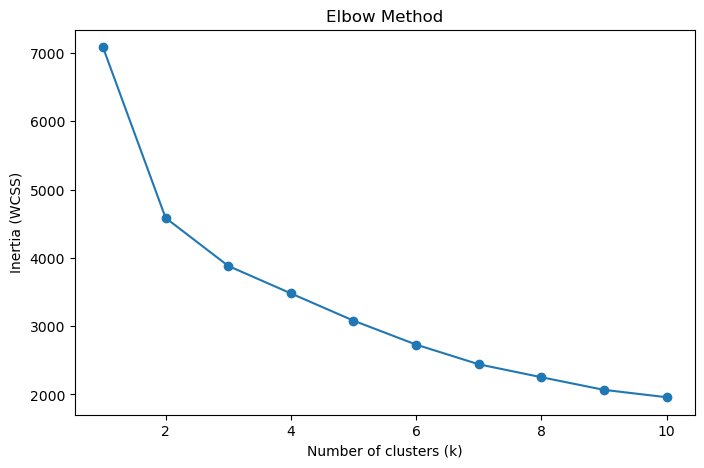

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(model)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.savefig("elbow_plot.png")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(model)
df['Cluster'] = clusters

print(df['Cluster'].value_counts())

Cluster
1    209
0    156
2    141
Name: count, dtype: int64


C:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


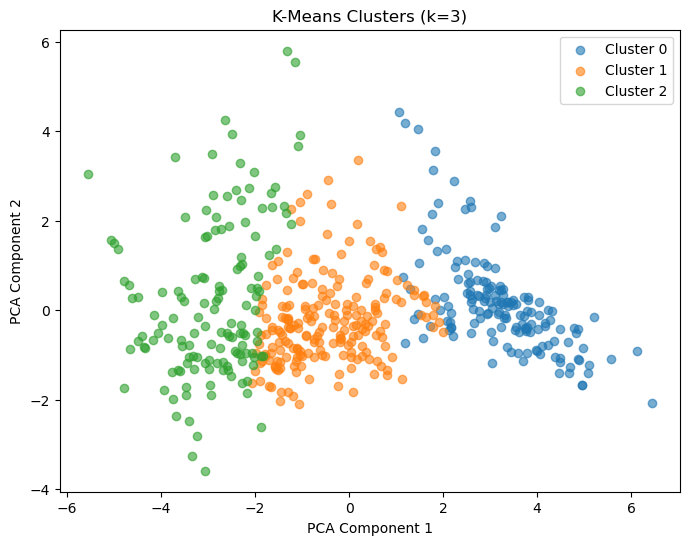

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(model)

plt.figure(figsize=(8, 6))
for c in sorted(df['Cluster'].unique()):
    mask = clusters == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {c}", alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (k=3)")
plt.legend()
plt.savefig("clusters_2d.png")
plt.show()

In [11]:
print(df.groupby('Cluster')[cols].mean().round(2))

          CRIM     ZN  INDUS  CHAS   NOX    RM    AGE   DIS    RAD     TAX  \
Cluster                                                                      
0        11.05   0.00  18.65  0.08  0.69  5.95  90.73  2.00  21.02  636.28   
1         0.38   2.16  10.04  0.07  0.52  6.09  69.26  3.86   4.45  315.83   
2         0.18  37.58   4.45  0.06  0.46  6.94  43.05  5.69   4.42  292.90   

         PTRATIO       B  LSTAT   MEDV  
Cluster                                 
0          19.69  293.35  19.00  16.19  
1          18.67  381.96  12.38  21.13  
2          16.77  389.25   6.04  31.63  
